In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from src.knn import KNN
from src.metrics import accuracy,recall,precision,f1_score,roc_auc
from src.splits import stratified_kfold
np.random.seed(42)
df=pd.read_csv('../data/titanic3.csv')
df['age']=df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df = pd.get_dummies(df, columns=['embarked'], drop_first=False)
df['embarked_C'] = df['embarked_C'].astype(int)
df['embarked_Q'] = df['embarked_Q'].astype(int)
df['embarked_S'] = df['embarked_S'].astype(int)
df.head()
df.columns.tolist()

['pclass',
 'survived',
 'name',
 'sex',
 'age',
 'sibsp',
 'parch',
 'ticket',
 'fare',
 'cabin',
 'boat',
 'body',
 'home.dest',
 'embarked_C',
 'embarked_Q',
 'embarked_S']

In [3]:
cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
        'embarked_C', 'embarked_Q', 'embarked_S']
X = df[cols].values
y = df['survived'].values

In [4]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]
results = []

for k in k_values:
    f1_scores = []
    for X_train, X_val, y_train, y_val in stratified_kfold(X, y, K=5):
        model = KNN(k=k, metric='euclidean')
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        f1_scores.append(f1_score(y_val, y_pred))
    
    results.append({
        'k': k,
        'mean_f1': np.mean(f1_scores),
        'std_f1': np.std(f1_scores)
    })

results_df = pd.DataFrame(results)
print(results_df)

    k   mean_f1    std_f1
0   1  0.557917  0.032673
1   3  0.537597  0.030652
2   5  0.552188  0.035746
3   7  0.548129  0.042180
4   9  0.531130  0.040046
5  11  0.543963  0.031620
6  15  0.553522  0.036314
7  21  0.527068  0.046452
8  31  0.492380  0.055987
9  51  0.487049  0.039079


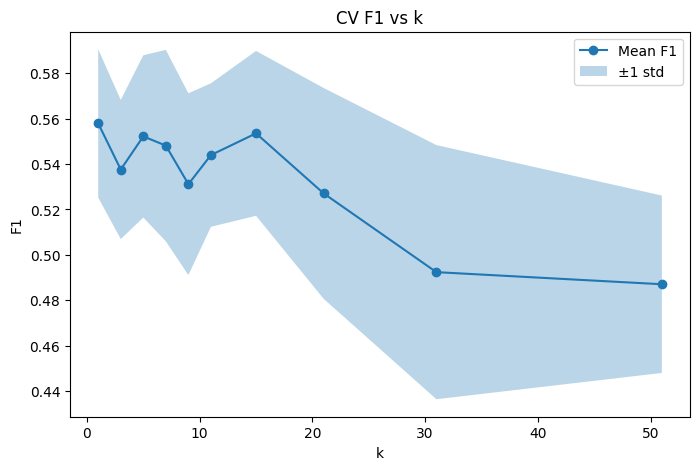

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(results_df['k'], results_df['mean_f1'], marker='o', label='Mean F1')
plt.fill_between(results_df['k'], 
                 results_df['mean_f1'] - results_df['std_f1'],
                 results_df['mean_f1'] + results_df['std_f1'],
                 alpha=0.3, label='±1 std')
plt.xlabel('k')
plt.ylabel('F1')
plt.title('CV F1 vs k')
plt.legend()
plt.savefig('../figures/cv_f1_vs_k.pdf')
plt.show()

#F1 in cox azalmaqi underfittinge yol aca biler yk

In [6]:
from sklearn.preprocessing import StandardScaler

k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]
results_scaled = []

for k in k_values:
    f1_scores = []
    for X_train, X_val, y_train, y_val in stratified_kfold(X, y, K=5):
        scaler = StandardScaler()
        X_train_scaled = scaler.fit(X_train).transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        
        model = KNN(k=k, metric='euclidean')
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)
        f1_scores.append(f1_score(y_val, y_pred))
    
    results_scaled.append({
        'k': k,
        'mean_f1': np.mean(f1_scores),
        'std_f1': np.std(f1_scores)
    })

results_scaled_df = pd.DataFrame(results_scaled)
print(results_scaled_df)

    k   mean_f1    std_f1
0   1  0.665705  0.022716
1   3  0.706308  0.021586
2   5  0.696151  0.022615
3   7  0.701179  0.041387
4   9  0.713711  0.023477
5  11  0.709531  0.023805
6  15  0.717722  0.022264
7  21  0.721022  0.028468
8  31  0.704280  0.022044
9  51  0.690227  0.043428


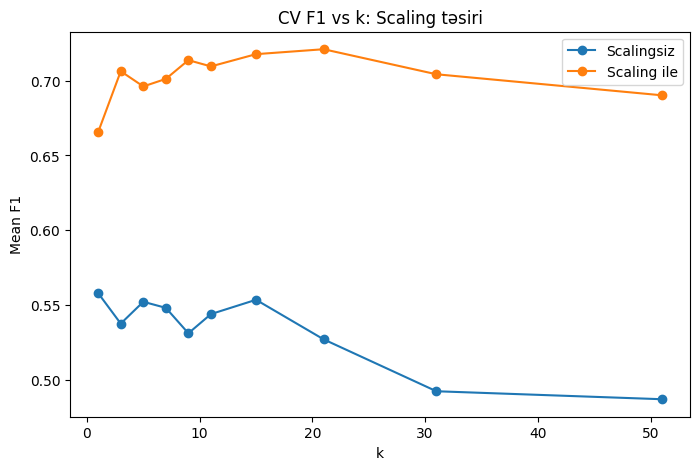

In [8]:
plt.figure(figsize=(8,5))
plt.plot(results_df['k'], results_df['mean_f1'], marker='o', label='Scalingsiz')
plt.plot(results_scaled_df['k'], results_scaled_df['mean_f1'], marker='o', label='Scaling ile')
plt.xlabel('k')
plt.ylabel('Mean F1')
plt.title('CV F1 vs k: Scaling təsiri')
plt.legend()
plt.savefig('../figures/scaling_effect.pdf')
plt.show()